# Airfoil Section Design Optimization
### MECH 559 — Systems Optimization — L01
### Course Instructor: Dr. Ahmed Bayoumy
Author of the notebook: Dr. Ahmed Bayoumy

This notebook illustrates the **analytical 2D airfoil design optimization** example from Lecture 01.

Design variables are the **NACA four-digit airfoil parameters** that control the section shape.
The lift coefficient $C_L$ is **not** chosen freely — it is *computed* from the shape via thin-airfoil
theory and held as a dependent quantity throughout the notebook, exactly like $C_D$ and $W_s$.

**Contents:**
1. Problem setup and analysis models — NACA design variables, computed $C_L$
   - 1b. Monotonicity table — selecting the functions of interest
   - 1c. Physical intuition (schematic) — why thin cuts drag but raises weight index
2. Design space exploration
   - 2b. Isolating the $\tau$-effect on $C_D$ at fixed camber $m=m_{\min}$
3. Classical single-objective: maximize $L/D$

In [28]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize, minimize_scalar, brentq
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

plt.rcParams.update({'font.size': 12, 'figure.dpi': 110})

---
## 1. Problem Setup and Analysis Models

We optimize a **wing section** described by a **NACA four-digit airfoil**:

$$\text{NACA } \underbrace{m}_{\text{1st digit}}\;\underbrace{p}_{\text{2nd digit}}\;\underbrace{tt}_{\text{last 2 digits}}$$

- $m$ = maximum camber (as % chord)
- $p$ = chordwise location of maximum camber (in tenths of chord)
- $\tau = t/c$ = maximum thickness ratio (as % chord)

### Design variables

Two of the three NACA parameters are treated as **active design variables**; the camber position
$p$ is held fixed (a common practical choice — most cambered NACA four-digit sections use $p=0.4$),
exactly like $AR$, $e$ etc. below are held fixed.

| Symbol | Meaning | Range |
|--------|---------|-------|
| $\tau = t/c$ | thickness-to-chord ratio (last 2 NACA digits) | $[0.06,\; 0.20]$ |
| $m$ | maximum camber (1st NACA digit) | $[m_{\min},\, m_{\max}]$ — *derived below* |

### Parameters

| Symbol | Meaning | Value |
|--------|---------|-------|
| $c_f$ | turbulent skin-friction coefficient | $0.003$ |
| $AR$ | wing aspect ratio | $8$ |
| $e$ | Oswald span-efficiency factor | $0.85$ |
| $k_s$ | structural weight coefficient | $0.009$ |
| $p$ | camber position (2nd NACA digit) | $0.40$ (fixed) |
| $\alpha_{\text{ref}}$ | operating angle of attack | $1.0°$ (fixed) |

### Lift is *computed*, not chosen

**Thin-airfoil theory** gives the lift coefficient of a cambered section as
$$C_L(m,\alpha) = 2\pi\bigl(\alpha - \alpha_{L0}(m,p)\bigr)$$
where $\alpha_{L0}(m,p)$ is the **zero-lift angle of attack** set entirely by the camber line shape
(derived in Section 3b). With $\alpha=\alpha_{\text{ref}}$ fixed, $C_L$ becomes a **pure function of
the shape variable $m$**: $C_L = C_L(m)$, monotonically increasing in $m$.

The mission's lift **requirement** — the operating range the section must be able to cover — is
still expressed as $C_L \in [C_{L,\min}, C_{L,\max}] = [0.20,\, 1.20]$, exactly as before. What
changes is that this requirement is now translated into bounds on the actual design variable:
$$m \in [m_{\min}, m_{\max}], \qquad \text{where } C_L(m_{\min}) = C_{L,\min},\;\; C_L(m_{\max}) = C_{L,\max}$$

### Analysis models

**Aerodynamic drag** (NACA profile drag correlation + induced drag):
$$C_D(\tau, m) = \underbrace{c_f\bigl(1 + 2\tau + 60\tau^4\bigr)}_{C_{D,p}(\tau)} + \underbrace{\frac{C_L(m)^2}{\pi\, AR\, e}}_{C_{D,i}(m)}$$

**Structural weight index** (thicker section → lighter spars for same span loading):
$$W_s(\tau) = \frac{k_s}{\tau}$$

**Functions of interest:** $\mathbf{f} = [C_D,\; W_s]^\top$ — both to be minimized, with
$C_L = C_L(m)$ tracked as a *computed dependent quantity* at every design point.

> **Conflict:** minimizing $C_D$ wants thin, low-camber airfoil ($\tau \to \tau_{\min}$,
> $m \to m_{\min}$), while minimizing $W_s$ wants thick airfoil ($\tau \to \tau_{\max}$). These
> are competing objectives.


In [29]:
# ── Fixed parameters ─────────────────────────────────────────────────────────
c_f = 0.003    # turbulent skin-friction coefficient
AR  = 8.0      # aspect ratio
e   = 0.85     # Oswald efficiency
k_s = 0.009    # structural weight coefficient

p_camber  = 0.40                # camber position, 2nd NACA digit -> fixed
alpha_ref = np.radians(1.0)     # fixed reference (operating) angle of attack

# ── NACA four-digit camber line + thin-airfoil lift model ─────────────────────
def naca4_dyc_dx(x, m, p=p_camber):
    '''Slope dyc/dx of the NACA four-digit mean camber line.'''
    x = np.atleast_1d(np.asarray(x, dtype=float))
    dydx = np.zeros_like(x)
    if m > 0:
        front = x < p
        dydx[front] = (2*m/p**2) * (p - x[front])
        back = ~front
        dydx[back] = (2*m/(1-p)**2) * (p - x[back])
    return dydx

def alpha_L0(m, p=p_camber, n=2000):
    '''Zero-lift angle of attack (rad) from thin-airfoil theory:
    alpha_L0 = -(1/pi) * int_0^pi (dyc/dx)(cos(theta)-1) dtheta,  x = (1-cos(theta))/2.'''
    if m == 0:
        return 0.0
    theta = np.linspace(1e-6, np.pi - 1e-6, n)
    x = 0.5 * (1 - np.cos(theta))
    dydx = naca4_dyc_dx(x, m, p)
    return -(1/np.pi) * np.trapz(dydx * (np.cos(theta) - 1), theta)

def CL_of_m_exact(m, p=p_camber, alpha=alpha_ref):
    '''Lift coefficient generated by camber m at the fixed operating alpha (thin-airfoil theory).'''
    return 2 * np.pi * (alpha - alpha_L0(m, p))

# Fast vectorized monotonic lookup (CL is monotone increasing in m) ------------
_m_table  = np.linspace(0.0, 0.20, 400)
# NumPy 2.x compatibility: np.trapz was replaced by np.trapezoid
if not hasattr(np, "trapz"):
  np.trapz = np.trapezoid

_CL_table = np.array([CL_of_m_exact(mi) for mi in _m_table])

def CL_of_m(m):
    '''Vectorized C_L(m): computed lift coefficient (thin-airfoil theory, interpolated).'''
    return np.interp(m, _m_table, _CL_table)

def m_of_CL(CL):
    '''Inverse map: camber m required to realize a target C_L (interpolated).'''
    return np.interp(CL, _CL_table, _m_table)

# ── Side constraints (design variable bounds) ─────────────────────────────────
tau_min, tau_max = 0.06, 0.20

# CL_min/CL_max are the MISSION lift requirements (unchanged from the original
# problem). m_min/m_max are the camber values that realize them at alpha_ref --
# i.e. the lift requirement is translated into bounds on the actual design variable m.
CL_min, CL_max = 0.20, 1.20
m_min = brentq(lambda m: CL_of_m_exact(m) - CL_min, 0.0, 0.20)
m_max = brentq(lambda m: CL_of_m_exact(m) - CL_max, 0.0, 0.20)

# ── Analysis models ───────────────────────────────────────────────────────────
def CD_profile(tau):
    '''NACA profile (zero-lift) drag.'''
    return c_f * (1 + 2*tau + 60*tau**4)

def CD_induced(CL):
    '''Induced drag.'''
    return CL**2 / (np.pi * AR * e)

def CD_total(tau, CL):
    return CD_profile(tau) + CD_induced(CL)

def Ws(tau):
    '''Structural weight index.'''
    return k_s / tau

def LD(tau, CL):
    return CL / CD_total(tau, CL)

# ── Sanity check ──────────────────────────────────────────────────────────────
tau0 = 0.12
m0   = brentq(lambda m: CL_of_m_exact(m) - 0.60, 0.0, 0.20)   # camber giving CL0 = 0.60
CL0  = CL_of_m(m0)

print(f"Design variable bounds:  tau in [{tau_min*100:.1f}%, {tau_max*100:.1f}%],"
      f"  m in [{m_min*100:.2f}%, {m_max*100:.2f}%]")
print(f"  (m_min, m_max realize the mission requirement CL in [{CL_min}, {CL_max}])\n")

print(f"At tau = {tau0:.2f}, m = {m0*100:.2f}% (NACA-type ~{m0*100:.0f}{p_camber*10:.0f}{tau0*100:.0f}):")
print(f"  CL (computed)  = {CL0:.4f}")
print(f"  CD_profile     = {CD_profile(tau0)*1e4:.1f} drag counts")
print(f"  CD_induced     = {CD_induced(CL0)*1e4:.1f} drag counts")
print(f"  CD_total       = {CD_total(tau0,CL0)*1e4:.1f} drag counts")
print(f"  L/D            = {LD(tau0,CL0):.1f}")
print(f"  Ws             = {Ws(tau0):.4f}")

Design variable bounds:  tau in [6.0%, 20.0%],  m in [0.79%, 9.57%]
  (m_min, m_max realize the mission requirement CL in [0.2, 1.2])

At tau = 0.12, m = 4.31% (NACA-type ~4412):
  CL (computed)  = 0.6000
  CD_profile     = 37.6 drag counts
  CD_induced     = 168.5 drag counts
  CD_total       = 206.1 drag counts
  L/D            = 29.1
  Ws             = 0.0750


---
### 1b. Monotonicity Table — Selecting the Functions of Interest

Before exploring the design space, we ask: **which quantities actually deserve to be tracked as
functions of interest** (objectives to trade off), and which are just constraints in disguise?
A **monotonicity table** answers this by recording the sign of $\partial f/\partial x$ for every
candidate function $f$ against every design variable $x$.

| Function of interest | Role | $\partial f/\partial \tau$ | $\partial f/\partial m$ |
|---|---|:---:|:---:|
| $C_D(\tau, m)$ | candidate objective (minimize) | $+$ | $+$ |
| $W_s(\tau)$ | candidate objective (minimize) | $-$ | $0$ |
| $C_L(m)$ | mission requirement ($C_L \geq C_{L,\min}$) | $0$ | $+$ |

**Reading the table:**

- **$\tau$ has opposite signs in $C_D$ ($+$) and $W_s$ ($-$).** Minimizing one pushes $\tau$ down,
  minimizing the other pushes it up — the sign conflict cannot be resolved by inspection alone.
  This is precisely the signature of a **genuine trade-off variable**, which is why $\tau$ is the
  variable we sweep in the $\varepsilon$-constraint study (Section 4).
- **$m$ has the *same* sign ($+$) everywhere it appears, and it is absent from $W_s$ entirely.**
  There is nothing pulling $m$ back down once $C_D$ pushes it toward its lower bound — so with no
  opposing objective, minimizing $C_D$ alone drives $m$ to the smallest value it is allowed to
  take. That lower bound is set not by an objective but by the mission requirement
  $C_L(m) \geq C_{L,\min}$, i.e. $m \geq m_{\min}$. A monotonically one-signed variable with no
  competing pull is therefore **not a trade-off variable at all** — its optimum is resolved directly
  by the bound, without needing a Pareto sweep. (This is exactly the $m^*=m_{\min}$ corner
  solution derived analytically in Section 4 and confirmed numerically in Section 5.)

**Why we chose $(C_D, W_s)$ as the functions of interest.** Only $\tau$ shows conflicting
monotonicity across candidate objectives — that conflict *is* the design trade-off, and $C_D$,
$W_s$ are the two functions between which it appears. $C_L$, despite being a genuine
physical quantity of the design, never has to be traded off against anything: monotonicity alone
pins $m$ to $m_{\min}$, so $C_L$ is demoted from a candidate objective to a simple floor
constraint on $m$. This is why the multi-objective formulation in Section 4 has only two
functions of interest, not three — the table below is verified numerically in the next cell.


In [30]:
# ── Verify the monotonicity table by central-difference partial derivatives ──
def partial_sign(f, x0, i, h=1e-6):
    '''Central-difference d f/d x_i at x0=[tau,m], returned as (value, sign string).'''
    xp, xm = list(x0), list(x0)
    xp[i] += h
    xm[i] -= h
    d = (f(xp) - f(xm)) / (2 * h)
    sign = '+' if d > 1e-9 else ('-' if d < -1e-9 else '0')
    return d, sign

f_CD = lambda x: CD_total(x[0], CL_of_m(x[1]))   # x = [tau, m]
f_Ws = lambda x: Ws(x[0])
f_CL = lambda x: CL_of_m(x[1])

sample_pts = [[0.08, 0.02], [0.12, 0.05], [0.18, 0.08]]   # a few interior (tau, m) points

header = f"{'(tau, m)':<14}{'dCD/dtau':>12}{'dCD/dm':>10}{'dWs/dtau':>12}{'dWs/dm':>10}{'dCL/dtau':>12}{'dCL/dm':>10}"
print(header)
print('-' * len(header))
for x0 in sample_pts:
    _, sCD_tau = partial_sign(f_CD, x0, 0)
    _, sCD_m   = partial_sign(f_CD, x0, 1)
    _, sWs_tau = partial_sign(f_Ws, x0, 0)
    _, sWs_m   = partial_sign(f_Ws, x0, 1)
    _, sCL_tau = partial_sign(f_CL, x0, 0)
    _, sCL_m   = partial_sign(f_CL, x0, 1)
    label = f"({x0[0]:.2f}, {x0[1]:.2f})"
    print(f"{label:<14}{sCD_tau:>12}{sCD_m:>10}{sWs_tau:>12}{sWs_m:>10}{sCL_tau:>12}{sCL_m:>10}")

print("\nSigns match the monotonicity table at every sampled point:")
print("  tau: conflicting (+ in CD, - in Ws)  -> genuine trade-off variable (swept in Section 4)")
print("  m:   one-signed  (+ in CD, 0 in Ws)   -> pinned to its bound m_min by monotonicity alone")

(tau, m)          dCD/dtau    dCD/dm    dWs/dtau    dWs/dm    dCL/dtau    dCL/dm
--------------------------------------------------------------------------------
(0.08, 0.02)             +         +           -         0           0         +
(0.12, 0.05)             +         +           -         0           0         +
(0.18, 0.08)             +         +           -         0           0         +

Signs match the monotonicity table at every sampled point:
  tau: conflicting (+ in CD, - in Ws)  -> genuine trade-off variable (swept in Section 4)
  m:   one-signed  (+ in CD, 0 in Ws)   -> pinned to its bound m_min by monotonicity alone


---
### 1c. Physical Intuition — Why Thin Cuts Drag but Raises Weight Index (and Vice Versa)

The monotonicity table above gives us the *signs* ($\partial C_D/\partial\tau > 0$,
$\partial W_s/\partial\tau < 0$); this schematic explains *why*, mechanism by mechanism.

**Drag ($C_{D,p}$ increasing in $\tau$):** a thinner section keeps the flow attached longer and
leaves a narrower wake behind it. A thicker section imposes a stronger adverse pressure gradient
on the flow as it tries to recover around the section's bulk, promoting earlier separation and a
wider wake — more momentum deficit, more profile drag.

**Structural weight index ($W_s = k_s/\tau$ decreasing in $\tau$):** the spar's two caps (flanges)
react the local bending moment $M$ as an internal force couple separated by the spar depth
$h_{spar}$, which scales with the local thickness. The cap force is
$$F \approx \frac{M}{h_{spar}}$$
so the cap material needed to carry $F$ at a given allowable stress scales as $1/h_{spar}$.
**A thin section has a shallow spar — a small moment arm — so it needs *more* cap material to
react the same bending moment: a heavier structure, not a lighter one**, despite its smaller
cross-section. A thick section's deeper spar gives a longer moment arm and needs less material —
lighter, lower $W_s$. This is exactly the mechanism $W_s(\tau) = k_s/\tau$ is standing in for —
and the same depth-vs-bending-efficiency effect reappears in the cantilever beam notebook, where
a taller section height $h$ needs less material to carry the same load.


---
## 2. Design Space Exploration

We visualize $C_D$, $L/D$, and $W_s$ over the feasible design space $(\tau, m)$. The lift
coefficient $C_L(m)$ is shown on a secondary axis — it is a *computed* quantity, not an
independent axis of the design space.

> **Reading the $C_D$ panel: why it looks almost flat along $\tau$.** $C_D = C_{D,p}(\tau) +
> C_{D,i}(m)$ sums two terms of very different size over this grid: $C_{D,p}(\tau)$ only swings
> from $\approx 33.6$ to $\approx 44.9$ drag counts across the full $\tau$ range (about 11
> counts), while $C_{D,i}(m)$ swings from $\approx 18.7$ counts at $C_L=C_{L,\min}$ up to
> $\approx 674$ counts at $C_L=C_{L,\max}$ (about 655 counts), because induced drag scales with
> $C_L^2$ and the mission $C_L$ range spans a factor of 6. So on this grid, camber's effect on
> $C_D$ is roughly **60× larger** than thickness's effect, and the color scale (which auto-scales
> to $C_D$'s own min/max) visually swallows the $\tau$-direction gradient. $\partial
> C_D/\partial\tau$ is still strictly positive everywhere (Section 1b) — it is just numerically
> small *here*.
>
> **This is not the same reason the $C_L$ axis is flat along $\tau$.** $C_L$'s independence from
> $\tau$ is not a matter of scale — it is *exact*, by construction: thin-airfoil theory
> (Section 3b) gives $C_L = C_L(m)$ only, with $\tau$ nowhere in the formula, so
> $\partial C_L/\partial\tau \equiv 0$ identically at every point, not just small. $C_D$'s
> flatness along $\tau$, by contrast, is a *visual* effect of this particular grid's scale — the
> $\tau$-sensitivity is real and strictly positive, it's just dominated by the camber term here.
>
> **Why this matters for the optimization to come:** once camber is pinned at $m_{\min}$ on the
> Pareto front (Section 4), $C_{D,i}$ sits near the *bottom* of its range and stops varying — so
> $\tau$ becomes the *only* thing driving $C_D$. The slice plot at the end of this section makes
> that $\tau$-effect directly visible, isolated from the camber sweep.


CD_profile(tau) range:  33.6 - 44.9 drag counts  (swing = 11.3 cts, driven by tau)
CD_induced(m)   range:  18.7 - 674.1 drag counts  (swing = 655.3 cts, driven by m via CL)
  -> camber's effect on CD is ~58x larger than thickness's effect over this grid; the CD color scale is dominated by m.
  -> CL(m), by contrast, is EXACTLY independent of tau (dCL/dtau = 0 identically, not just small).


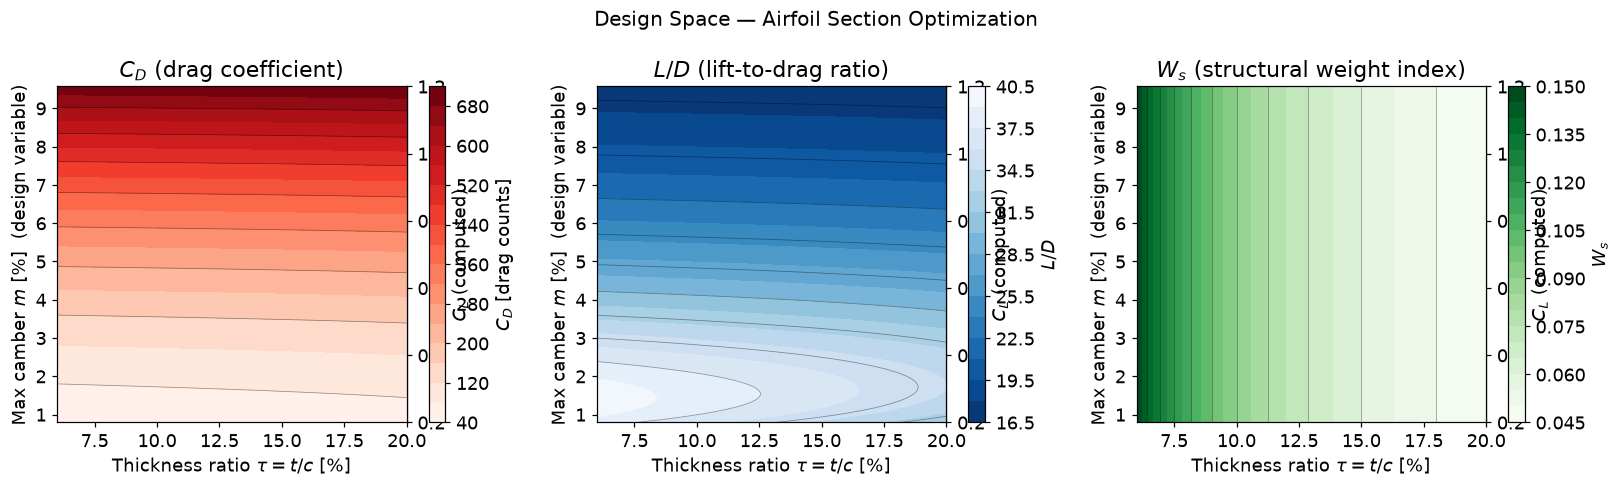

In [31]:
tau_vals = np.linspace(tau_min, tau_max, 300)
m_vals   = np.linspace(m_min,   m_max,   300)
CL_vals  = CL_of_m(m_vals)                       # computed C_L, monotone in m

TAU, M_grid = np.meshgrid(tau_vals, m_vals)
CL_grid = CL_of_m(M_grid)                        # computed lift coefficient
CD_grid = CD_total(TAU, CL_grid)
LD_grid = CL_grid / CD_grid
Ws_grid = Ws(TAU)               # depends only on tau

# ── Quantify why the CD panel looks flat along tau (see markdown note above) ──
CDp_range = CD_profile(tau_vals)
CDi_range = CD_induced(CL_vals)
print(f"CD_profile(tau) range:  {CDp_range.min()*1e4:.1f} - {CDp_range.max()*1e4:.1f} drag counts"
      f"  (swing = {(CDp_range.max()-CDp_range.min())*1e4:.1f} cts, driven by tau)")
print(f"CD_induced(m)   range:  {CDi_range.min()*1e4:.1f} - {CDi_range.max()*1e4:.1f} drag counts"
      f"  (swing = {(CDi_range.max()-CDi_range.min())*1e4:.1f} cts, driven by m via CL)")
print(f"  -> camber's effect on CD is ~{(CDi_range.max()-CDi_range.min())/(CDp_range.max()-CDp_range.min()):.0f}x"
      f" larger than thickness's effect over this grid; the CD color scale is dominated by m.")
print(f"  -> CL(m), by contrast, is EXACTLY independent of tau (dCL/dtau = 0 identically, not just small).")

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

titles  = ['$C_D$ (drag coefficient)', '$L/D$ (lift-to-drag ratio)', '$W_s$ (structural weight index)']
grids   = [CD_grid * 1e4, LD_grid, Ws_grid]
clabels = ['$C_D$ [drag counts]', '$L/D$', '$W_s$']
cmaps   = ['Reds', 'Blues_r', 'Greens']

for ax, G, title, clabel, cmap in zip(axes, grids, titles, clabels, cmaps):
    cs = ax.contourf(tau_vals * 100, m_vals * 100, G, levels=20, cmap=cmap)
    ax.contour(tau_vals * 100, m_vals * 100, G, levels=10, colors='k', linewidths=0.5, alpha=0.4)
    plt.colorbar(cs, ax=ax, label=clabel)
    ax.set_xlabel('Thickness ratio $\\tau = t/c$ [%]')
    ax.set_ylabel('Max camber $m$ [%]  (design variable)')
    secax = ax.secondary_yaxis('right',
                                functions=(lambda mm: CL_of_m(mm/100), lambda cl: m_of_CL(cl)*100))
    secax.set_ylabel('$C_L$ (computed)')
    ax.set_title(title)
    ax.grid(False)

plt.suptitle('Design Space — Airfoil Section Optimization', fontsize=13)
plt.tight_layout()
plt.show()

### 2b. Isolating the $\tau$-Effect: $C_D$ at Fixed Camber $m=m_{\min}$

The panel above mixes the $\tau$- and $m$-effects on $C_D$ on one color scale, and the $m$-effect
dominates. But the actual Pareto front (Section 4) always sits at $m=m_{\min}$ — camber never
varies there. Slicing the design space at that fixed camber isolates exactly the $\tau$-dependence
that will matter for the optimization, with its own (non-swamped) axis.


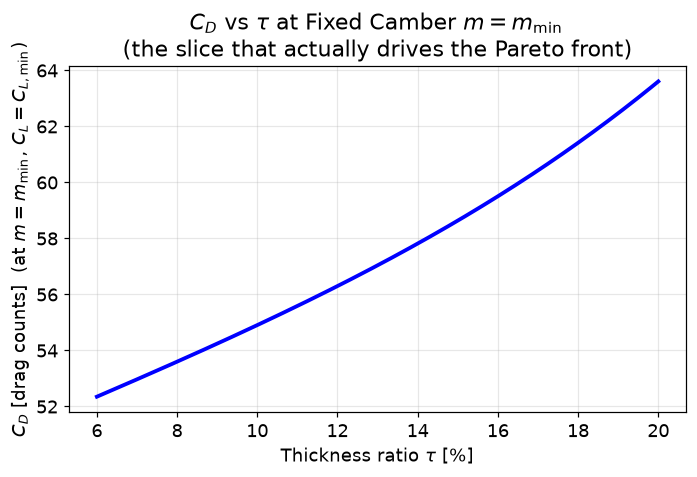

At m = m_min (CL = 0.2): CD ranges from 52.3 to 63.6 drag counts
  (11.3-count swing, entirely due to tau -- now clearly visible)
  Compare to the full-grid CD range, which reaches up to 674 cts of induced
  drag alone once camber is swept up to CL_max -- that's what swamped the tau-effect above.


In [32]:
# ── Supplementary slice: CD vs tau at fixed m = m_min (the Pareto-relevant slice) ──
CD_slice = CD_total(tau_vals, CL_min)   # camber pinned at its lower bound (CL = CL_min)

fig, ax = plt.subplots(figsize=(6.5, 4.5))
ax.plot(tau_vals * 100, CD_slice * 1e4, 'b-', lw=2.5)
ax.set_xlabel('Thickness ratio $\\tau$ [%]')
ax.set_ylabel('$C_D$ [drag counts]  (at $m=m_{\\min}$, $C_L=C_{L,\\min}$)')
ax.set_title('$C_D$ vs $\\tau$ at Fixed Camber $m=m_{\\min}$\n(the slice that actually drives the Pareto front)')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"At m = m_min (CL = {CL_min}): CD ranges from {CD_slice.min()*1e4:.1f} to {CD_slice.max()*1e4:.1f} drag counts")
print(f"  ({(CD_slice.max()-CD_slice.min())*1e4:.1f}-count swing, entirely due to tau -- now clearly visible)")
print(f"  Compare to the full-grid CD range, which reaches up to {CD_induced(CL_max)*1e4:.0f} cts of induced")
print(f"  drag alone once camber is swept up to CL_max -- that's what swamped the tau-effect above.")

---
## 3. Classical Single-Objective: Maximize $L/D$

For a **fixed thickness** $\tau$, the optimal $C_L$ that maximizes lift-to-drag ratio satisfies:
$$\frac{\partial}{\partial C_L}\!\left(\frac{C_L}{C_D}\right) = 0
\;\Longrightarrow\; C_{D,p}(\tau) = C_{D,i}(C_L^*)$$

i.e., **profile drag = induced drag** at maximum $L/D$. Solving:
$$C_L^*(\tau) = \sqrt{C_{D,p}(\tau)\cdot\pi\, AR\, e}, \qquad
C_D^* = 2\,C_{D,p}(\tau), \qquad
\left(\frac{L}{D}\right)^* = \frac{1}{2}\sqrt{\frac{\pi\, AR\, e}{C_{D,p}(\tau)}}$$

This condition on $C_L^*$ is unchanged by the reparametrization — it is a statement about the
*drag model*. What is new is that $C_L^*(\tau)$ is now a **target** that must be *realized* by a
shape: we invert the computed lift model $C_L(m)$ to find the camber
$$m^*(\tau) = C_L^{-1}\bigl(C_L^*(\tau)\bigr)$$
that actually produces it, using the numerical inverse built in Section 1 (and `brentq` for an
exact check at the overall optimum).

> **Scope note.** This is the *classical* single-objective sub-problem: maximize $L/D$ alone,
> optimizing over $\tau$ as well. It answers a genuinely different question from Section 4's
> multi-objective problem (minimize $C_D$ subject to a structural-weight bound), and the two do
> **not** share the same optimum — the camber $m^*$ found here will turn out to differ from the
> $m^*=m_{\min}$ that is actually Pareto-optimal (Section 4). We keep this sub-problem only to
> contrast the two design philosophies in Section 3c; do not read its result as "the" optimized
> airfoil for the full mass/drag tradeoff.


Unconstrained best L/D (over tau):
  tau* = 6.00%,  CL* = 0.2680  ->  m* = 1.39%  (design variable)
  (L/D)* = 39.85
  CD* = 67.2 drag counts
  Ws* = 0.1500
  NOTE: this is the max-L/D optimum, NOT the Pareto-optimal design of Section 4.
        At this same tau, Section 4 gives m*=m_min=0.79% and CD*=52.3 drag counts -- lower drag, less camber.


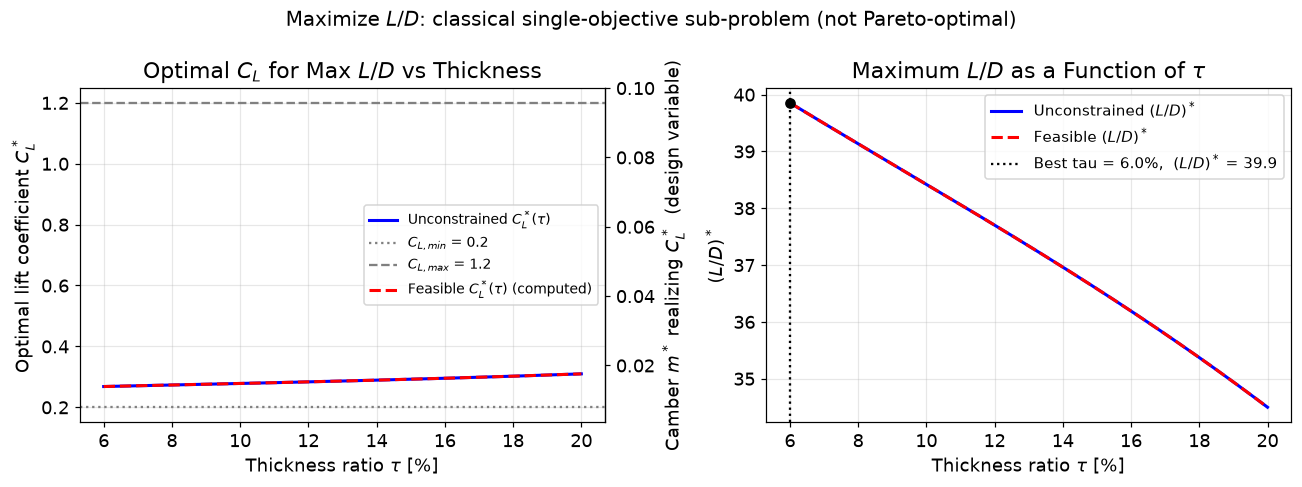

In [33]:
# ── Analytical optimum CL*(tau) for max L/D ──────────────────────────────────
tau_sweep = np.linspace(tau_min, tau_max, 300)
CDp_sweep = CD_profile(tau_sweep)

CL_opt_LD  = np.sqrt(CDp_sweep * np.pi * AR * e)
CD_opt_LD  = 2 * CDp_sweep
LD_opt     = 0.5 * np.sqrt(np.pi * AR * e / CDp_sweep)

# Clip to feasible CL range (mission requirement)
CL_opt_LD_feas = np.clip(CL_opt_LD, CL_min, CL_max)
LD_feas        = CL_opt_LD_feas / CD_total(tau_sweep, CL_opt_LD_feas)

# Camber m*(tau) that REALIZES the target CL*(tau) -- computed, not chosen
m_opt_LD_feas = m_of_CL(CL_opt_LD_feas)

# Best overall: also optimize tau
idx_best = np.argmax(LD_feas)
tau_best = tau_sweep[idx_best]
CL_best  = CL_opt_LD_feas[idx_best]
LD_best  = LD_feas[idx_best]
m_best   = brentq(lambda m: CL_of_m_exact(m) - CL_best, 0.0, 0.20)   # exact inversion

print(f"Unconstrained best L/D (over tau):")
print(f"  tau* = {tau_best*100:.2f}%,  CL* = {CL_best:.4f}  ->  m* = {m_best*100:.2f}%  (design variable)")
print(f"  (L/D)* = {LD_best:.2f}")
print(f"  CD* = {CD_total(tau_best, CL_best)*1e4:.1f} drag counts")
print(f"  Ws* = {Ws(tau_best):.4f}")
print(f"  NOTE: this is the max-L/D optimum, NOT the Pareto-optimal design of Section 4.")
print(f"        At this same tau, Section 4 gives m*=m_min={m_min*100:.2f}% and "
      f"CD*={CD_total(tau_best, CL_min)*1e4:.1f} drag counts -- lower drag, less camber.")

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# Left: CL*(tau) for max L/D vs feasible bound, with m*(tau) on secondary axis
ax = axes[0]
ax.plot(tau_sweep*100, CL_opt_LD, 'b-', lw=2, label='Unconstrained $C_L^*(\\tau)$')
ax.axhline(CL_min, color='gray', ls=':', lw=1.5, label=f'$C_{{L,min}}$ = {CL_min}')
ax.axhline(CL_max, color='gray', ls='--', lw=1.5, label=f'$C_{{L,max}}$ = {CL_max}')
ax.plot(tau_sweep*100, CL_opt_LD_feas, 'r--', lw=2, label='Feasible $C_L^*(\\tau)$ (computed)')
ax.set_xlabel('Thickness ratio $\\tau$ [%]')
ax.set_ylabel('Optimal lift coefficient $C_L^*$')
secax = ax.secondary_yaxis('right', functions=(m_of_CL, CL_of_m))
secax.set_ylabel('Camber $m^*$ realizing $C_L^*$  (design variable)')
ax.set_title('Optimal $C_L$ for Max $L/D$ vs Thickness')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# Right: (L/D)* vs tau
ax = axes[1]
ax.plot(tau_sweep*100, LD_opt, 'b-', lw=2, label='Unconstrained $(L/D)^*$')
ax.plot(tau_sweep*100, LD_feas, 'r--', lw=2, label='Feasible $(L/D)^*$')
ax.axvline(tau_best*100, color='k', ls=':', lw=1.5,
           label=f'Best tau = {tau_best*100:.1f}%,  $(L/D)^*$ = {LD_best:.1f}')
ax.scatter([tau_best*100], [LD_best], color='k', zorder=5)
ax.set_xlabel('Thickness ratio $\\tau$ [%]')
ax.set_ylabel('$(L/D)^*$')
ax.set_title('Maximum $L/D$ as a Function of $\\tau$')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

plt.suptitle('Maximize $L/D$: classical single-objective sub-problem (not Pareto-optimal)', fontsize=13)
plt.tight_layout()
plt.show()

---
### 3b. Thin-Airfoil Theory with Camber — Computing $C_L$ from the NACA Shape

The NACA four-digit mean camber line is the piecewise parabola
$$y_c(x) = \begin{cases}
\dfrac{m}{p^2}\bigl(2px - x^2\bigr), & 0 \le x \le p \\[4pt]
\dfrac{m}{(1-p)^2}\bigl((1-2p) + 2px - x^2\bigr), & p \le x \le 1
\end{cases}$$

Classical thin-airfoil theory (Glauert) gives the **zero-lift angle of attack** as an integral of
the camber-line slope, using the substitution $x = \tfrac12(1-\cos\theta)$:
$$\alpha_{L0}(m,p) = -\frac{1}{\pi}\int_0^{\pi} \frac{dy_c}{dx}\bigl(\cos\theta - 1\bigr)\, d\theta$$

and the lift-curve slope is the universal thin-airfoil result $dC_L/d\alpha = 2\pi$, independent
of camber. Hence:
$$\boxed{C_L(m,\alpha) = 2\pi\bigl(\alpha - \alpha_{L0}(m,p)\bigr)}$$

With $\alpha=\alpha_{\text{ref}}$ and $p=p_{\text{camber}}$ **fixed** (Section 1), this is a
one-to-one, monotonically increasing map $C_L(m)$ — this is exactly `CL_of_m_exact` /
`CL_of_m` defined above, and the reason a symmetric section ($m=0$) at $\alpha_{\text{ref}}>0$
already produces some lift while a cambered section produces more.

*(Contrast with the classic symmetric-airfoil result $C_L = 2\pi\sin\alpha \approx 2\pi\alpha$:
that is the special case $m=0 \Rightarrow \alpha_{L0}=0$ of the model above.)*


Thin-airfoil-theory check (NACA 24xx camber, m=0.02, p=0.4):
  alpha_L0 = -2.08 deg  (classical textbook value for NACA 2412 is approx -2 deg)

Inverse-map check: m=0.0450 -> CL=0.6222 -> m_back=0.0450  (max error = 6.94e-18)


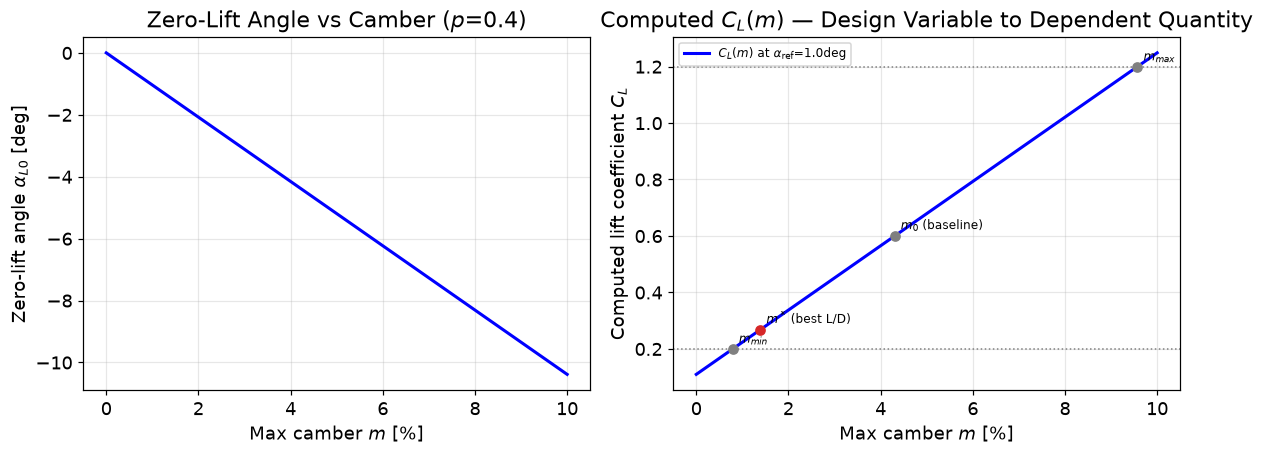

In [34]:
# ── Validate / visualize the camber-lift model ───────────────────────────────
m_check = 0.02   # NACA 2412-type camber
print(f"Thin-airfoil-theory check (NACA 24xx camber, m={m_check}, p={p_camber}):")
print(f"  alpha_L0 = {np.degrees(alpha_L0(m_check)):.2f} deg"
      "  (classical textbook value for NACA 2412 is approx -2 deg)")

# Cross-check the interpolated inverse against the exact brentq inverse
m_test  = 0.045
CL_test = CL_of_m(m_test)
m_back  = brentq(lambda m: CL_of_m_exact(m) - CL_test, 0.0, 0.20)
print(f"\nInverse-map check: m={m_test:.4f} -> CL={CL_test:.4f} -> m_back={m_back:.4f}"
      f"  (max error = {abs(m_test-m_back):.2e})")

fig, axes = plt.subplots(1, 2, figsize=(11, 4.3))

m_plot = np.linspace(0, 0.10, 200)
ax = axes[0]
ax.plot(m_plot*100, [np.degrees(alpha_L0(mi)) for mi in m_plot], 'b-', lw=2)
ax.set_xlabel('Max camber $m$ [%]')
ax.set_ylabel(r'Zero-lift angle $\alpha_{L0}$ [deg]')
ax.set_title(r'Zero-Lift Angle vs Camber ($p$=%.1f)' % p_camber)
ax.grid(True, alpha=0.3)

ax = axes[1]
ax.plot(m_plot*100, CL_of_m(m_plot), 'b-', lw=2, label=r'$C_L(m)$ at $\alpha_{\rm ref}$='
        f'{np.degrees(alpha_ref):.1f}deg')
for mv, lbl, col in [(m_min, '$m_{min}$', 'gray'), (m_max, '$m_{max}$', 'gray'),
                      (m0, '$m_0$ (baseline)', 'tab:gray'), (m_best, '$m^*$ (best L/D)', 'tab:red')]:
    ax.scatter([mv*100], [CL_of_m(mv)], color=col, zorder=5)
    ax.annotate(lbl, (mv*100, CL_of_m(mv)), textcoords='offset points', xytext=(4, 4), fontsize=8)
ax.axhline(CL_min, color='gray', ls=':', lw=1)
ax.axhline(CL_max, color='gray', ls=':', lw=1)
ax.set_xlabel('Max camber $m$ [%]')
ax.set_ylabel('Computed lift coefficient $C_L$')
ax.set_title('Computed $C_L(m)$ — Design Variable to Dependent Quantity')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
### 3c. Airfoil Shape — Baseline vs. Max-$L/D$ Design

The full NACA four-digit section combines the camber line $y_c(x)$ with the symmetric thickness
distribution $y_t(x)$:
$$y_t(x) = 5\tau\left(0.2969\sqrt{x} - 0.1260\,x - 0.3516\,x^2 + 0.2843\,x^3 - 0.1036\,x^4\right)$$

*(The trailing coefficient here is $-0.1036$, the closed-trailing-edge variant of the standard
NACA formula — it forces $y_t(1)=0$ so the upper and lower surfaces meet exactly at the trailing
edge. The original NACA report uses $-0.1015$, which leaves a small open gap at $x=1$; either is
fine, we just need to be consistent, and closed-TE is more convenient for plotting.)*

wrapped normal to the camber line ($\theta_c = \tan^{-1}(dy_c/dx)$):
$$x_{u,l} = x \mp y_t\sin\theta_c, \qquad y_{u,l} = y_c \pm y_t\cos\theta_c$$

Both design variables ($\tau$, $m$) now show up directly in the airfoil's **geometry** — unlike
the earlier symmetric-only NACA00xx model, camber is visible as curvature of the mean line, and
it is this curvature (not angle of attack, which is fixed at $\alpha_{\text{ref}}$ for both
designs) that produces the extra lift of the max-$L/D$ section.

We compare the **baseline** section ($\tau_0=0.12$, $m_0$, from Section 1) against the
**max-$L/D$** section ($\tau^*, m^*$ from Section 3's single-objective sub-problem), both flown
at the same $\alpha_{\text{ref}}$, annotated with their *computed* $C_L$ and $L/D$.

> **This is not the Pareto-optimal design.** The max-$L/D$ shape shown below optimizes a
> different objective than the multi-objective problem solved in Section 4 (minimize $C_D$
> subject to a structural-weight bound). At the same $\tau$, the actual Pareto-optimal camber is
> $m_{\min}$ (Section 4), which gives strictly *lower* drag than the $m^*$ used here — compare
> the printed numbers in Section 3's output cell to the Pareto endpoints in Section 4-5.


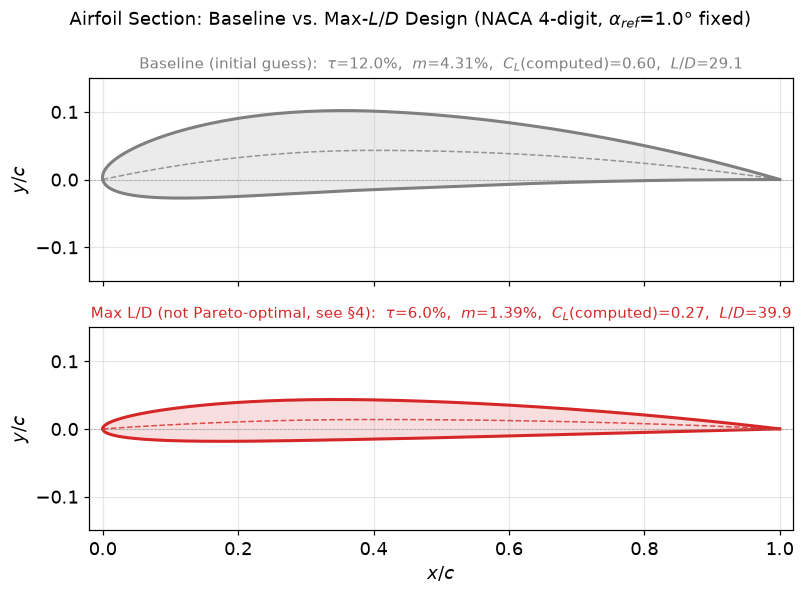

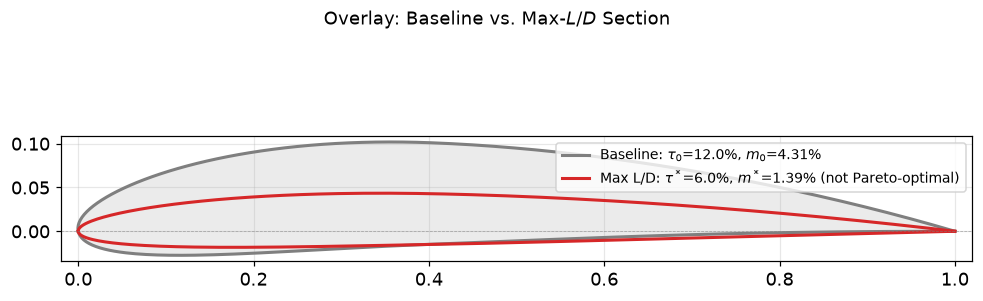

In [35]:
# ── Full NACA four-digit geometry (camber + thickness) ────────────────────────
def naca4_airfoil(m, p, tau, n_pts=200):
    '''Upper/lower surface coordinates of a cambered NACA four-digit section.'''
    beta = np.linspace(0, np.pi, n_pts)
    x = 0.5 * (1 - np.cos(beta))              # cosine spacing, clusters near LE/TE
    yt = 5 * tau * (0.2969*np.sqrt(x) - 0.1260*x - 0.3516*x**2
                    + 0.2843*x**3 - 0.1036*x**4)   # -0.1036 closes the TE

    if m > 0:
        yc = np.where(x < p,
                       (m/p**2) * (2*p*x - x**2),
                       (m/(1-p)**2) * ((1-2*p) + 2*p*x - x**2))
        dydx = naca4_dyc_dx(x, m, p)
    else:
        yc = np.zeros_like(x)
        dydx = np.zeros_like(x)
    theta_c = np.arctan(dydx)

    xu, yu = x - yt*np.sin(theta_c), yc + yt*np.cos(theta_c)
    xl, yl = x + yt*np.sin(theta_c), yc - yt*np.cos(theta_c)
    return xu, yu, xl, yl, x, yc

def plot_airfoil(ax, m, p, tau, label, color, CL=None, LD=None):
    xu, yu, xl, yl, xc, yc = naca4_airfoil(m, p, tau)
    ax.fill(np.r_[xu, xl[::-1]], np.r_[yu, yl[::-1]], color=color, alpha=0.15)
    ax.plot(xu, yu, color=color, lw=2)
    ax.plot(xl, yl, color=color, lw=2)
    ax.plot(xc, yc, color=color, lw=1, ls='--', alpha=0.8)
    info = f'{label}:  ' + r'$\tau$' + f'={tau*100:.1f}%,  $m$={m*100:.2f}%'
    if CL is not None:
        info += f',  $C_L$(computed)={CL:.2f}'
    if LD is not None:
        info += f',  $L/D$={LD:.1f}'
    ax.set_title(info, fontsize=10, color=color)
    ax.set_xlim(-0.02, 1.02)
    ax.set_ylim(-0.15, 0.15)
    ax.set_aspect('equal')
    ax.axhline(0, color='gray', lw=0.5, ls='--', alpha=0.6)
    ax.grid(True, alpha=0.3)

# Baseline design (Section 1 sanity check) vs max-L/D design (Section 3, NOT Pareto-optimal)
LD0 = LD(tau0, CL0)

fig, axes = plt.subplots(2, 1, figsize=(9, 5.5), sharex=True)
plot_airfoil(axes[0], m0, p_camber, tau0, 'Baseline (initial guess)', 'tab:gray', CL=CL0, LD=LD0)
plot_airfoil(axes[1], m_best, p_camber, tau_best, 'Max L/D (not Pareto-optimal, see §4)', 'tab:red', CL=CL_best, LD=LD_best)
axes[1].set_xlabel('$x/c$')
for ax in axes:
    ax.set_ylabel('$y/c$')

plt.suptitle(fr'Airfoil Section: Baseline vs. Max-$L/D$ Design (NACA 4-digit, $\alpha_{{ref}}$={np.degrees(alpha_ref):.1f}$\degree$ fixed)',
             fontsize=12)
plt.tight_layout()
plt.show()

# Overlay comparison
fig, ax = plt.subplots(figsize=(9, 3.2))
xu0, yu0, xl0, yl0, _, _ = naca4_airfoil(m0, p_camber, tau0)
ax.fill(np.r_[xu0, xl0[::-1]], np.r_[yu0, yl0[::-1]], color='tab:gray', alpha=0.15)
ax.plot(xu0, yu0, color='tab:gray', lw=2, label=f'Baseline: $\\tau_0$={tau0*100:.1f}%, $m_0$={m0*100:.2f}%')
ax.plot(xl0, yl0, color='tab:gray', lw=2)

xu1, yu1, xl1, yl1, _, _ = naca4_airfoil(m_best, p_camber, tau_best)
ax.plot(xu1, yu1, color='tab:red', lw=2, label=f'Max L/D: $\\tau^*$={tau_best*100:.1f}%, $m^*$={m_best*100:.2f}% (not Pareto-optimal)')
ax.plot(xl1, yl1, color='tab:red', lw=2)

ax.set_xlim(-0.02, 1.02)
ax.set_aspect('equal')
ax.axhline(0, color='gray', lw=0.5, ls='--', alpha=0.6)
ax.grid(True, alpha=0.3)
ax.legend(loc='upper right', fontsize=9)
plt.suptitle('Overlay: Baseline vs. Max-$L/D$ Section', fontsize=12)
plt.tight_layout()
plt.show()

---
## 4. Multi-Objective Problem and $\varepsilon$-Constraint Method

We now pose the full competing-objective problem in terms of the **actual design variables**
$(\tau, m)$:
$$\min_{\tau,\, m} \; \mathbf{f}(\tau, m) =
\begin{bmatrix} C_D\bigl(\tau, C_L(m)\bigr) \\ W_s(\tau) \end{bmatrix}$$

Because $W_s$ depends **only** on $\tau$ while $C_D$ depends on both variables, we use
the **$\varepsilon$-constraint method** — fix the structural weight bound and minimize drag:

$$\min_{\tau,\, m} \; C_D\bigl(\tau, C_L(m)\bigr) \quad \text{s.t.} \quad
W_s(\tau) \leq \varepsilon_k, \quad m \geq m_{\min}, \quad
\tau \in [\tau_{\min}, \tau_{\max}], \quad m \in [m_{\min}, m_{\max}]$$

### Analytical solution

Since $C_D$ is **monotonically increasing** in $\tau$, and $C_L(m)$ (hence $C_{D,i}$) is
**monotonically increasing** in $m$ (thin-airfoil theory, Section 3b):

- Optimal $m^* = m_{\min}$ (active lower bound — realizes $C_L^*=C_{L,\min}$, minimizing induced drag)
- Structural constraint $W_s \leq \varepsilon_k$ means $\tau \geq k_s/\varepsilon_k$, which is **always active** → $\tau^* = k_s/\varepsilon_k$

$$\boxed{\tau^*(\varepsilon_k) = \frac{k_s}{\varepsilon_k}, \qquad m^* = m_{\min}, \qquad
C_D^*(\varepsilon_k) = c_f\!\left(1 + \frac{2k_s}{\varepsilon_k} + 60\left(\frac{k_s}{\varepsilon_k}\right)^4\right)
+ \frac{C_{L,\min}^2}{\pi\,AR\,e}}$$

This is valid for $\varepsilon_k \in [k_s/\tau_{\max},\; k_s/\tau_{\min}] = [0.045,\; 0.15]$.


In [36]:
# ── Pareto front bounds ───────────────────────────────────────────────────────
eps_lo = k_s / tau_max   # tightest feasible W_s bound  (tau* = tau_max)
eps_hi = k_s / tau_min   # loosest  feasible W_s bound  (tau* = tau_min)
print(f"Valid eps_k range: [{eps_lo:.4f}, {eps_hi:.4f}]")
print(f"  (corresponds to tau* in [{tau_min*100:.0f}%, {tau_max*100:.0f}%])")
print(f"  Optimal camber is m* = m_min = {m_min*100:.2f}%  (realizes CL* = CL_min = {CL_min})")

# ── Analytical Pareto front ───────────────────────────────────────────────────
n_pts = 200
eps_sweep  = np.linspace(eps_lo, eps_hi, n_pts)
tau_pareto = k_s / eps_sweep                              # tau* = k_s / eps_k
m_pareto   = np.full(n_pts, m_min)                        # m* = m_min (design variable)
CL_pareto  = np.full(n_pts, CL_min)                        # CL* = CL_min (computed)
CD_pareto  = CD_total(tau_pareto, CL_pareto)              # CD*
Ws_pareto  = eps_sweep                                    # W_s* = eps_k (active constraint)

print(f"\nPareto front endpoints:")
print(f"  tau_max end: tau* = {tau_max*100:.0f}%,  CD* = {CD_total(tau_max,CL_min)*1e4:.1f} cts,  Ws* = {Ws(tau_max):.4f}")
print(f"  tau_min end: tau* = {tau_min*100:.0f}%,  CD* = {CD_total(tau_min,CL_min)*1e4:.1f} cts,  Ws* = {Ws(tau_min):.4f}")

# ── Verify: constraint activity ───────────────────────────────────────────────
err_Ws = np.max(np.abs(Ws(tau_pareto) - eps_sweep))
print(f"\nConstraint activity check:")
print(f"  max |Ws(tau*) - eps_k| = {err_Ws:.2e}  (should be 0)")

Valid eps_k range: [0.0450, 0.1500]
  (corresponds to tau* in [6%, 20%])
  Optimal camber is m* = m_min = 0.79%  (realizes CL* = CL_min = 0.2)

Pareto front endpoints:
  tau_max end: tau* = 20%,  CD* = 63.6 cts,  Ws* = 0.0450
  tau_min end: tau* = 6%,  CD* = 52.3 cts,  Ws* = 0.1500

Constraint activity check:
  max |Ws(tau*) - eps_k| = 2.78e-17  (should be 0)


---
## 5. Pareto Front — Analytical vs Numerical

We verify the analytical Pareto front against `scipy.optimize.minimize` (SLSQP), optimizing
directly over the actual design variables $(\tau, m)$ — the numerical solver never sees $C_L$
as a free variable; it only sees $C_L(m)$ through the objective function.


In [37]:
# ── Numerical Pareto front via eps-constraint ──────────────────────────────────
n_num    = 60
eps_num  = np.linspace(eps_lo * 1.02, eps_hi * 0.98, n_num)  # stay inside valid range
bounds_x = [(tau_min, tau_max), (m_min, m_max)]

CD_num, Ws_num, tau_num, m_num, CL_num = [], [], [], [], []

for eps_k in eps_num:
    cons = [{'type': 'ineq', 'fun': lambda x, e=eps_k: e - Ws(x[0])}]
    res  = minimize(lambda x: CD_total(x[0], CL_of_m(x[1])),
                    x0=[k_s/eps_k, m_min + 0.001],
                    method='SLSQP', bounds=bounds_x, constraints=cons,
                    options={'ftol': 1e-12, 'maxiter': 500})
    if res.success:
        tau_num.append(res.x[0])
        m_num.append(res.x[1])
        CL_num.append(CL_of_m(res.x[1]))
        CD_num.append(CD_total(res.x[0], CL_of_m(res.x[1])))
        Ws_num.append(Ws(res.x[0]))

tau_num = np.array(tau_num)
m_num   = np.array(m_num)
CL_num  = np.array(CL_num)
CD_num  = np.array(CD_num)
Ws_num  = np.array(Ws_num)

print(f"Numerical: {len(CD_num)}/{n_num} solutions converged.")
print(f"Max |CD_analytic - CD_numeric| = {np.max(np.abs(np.interp(Ws_num, Ws_pareto, CD_pareto) - CD_num)):.2e}")
print(f"Max |m_numeric - m_min|        = {np.max(np.abs(m_num - m_min)):.2e}  (confirms m* = m_min)")

Numerical: 60/60 solutions converged.
Max |CD_analytic - CD_numeric| = 1.06e-07
Max |m_numeric - m_min|        = 0.00e+00  (confirms m* = m_min)


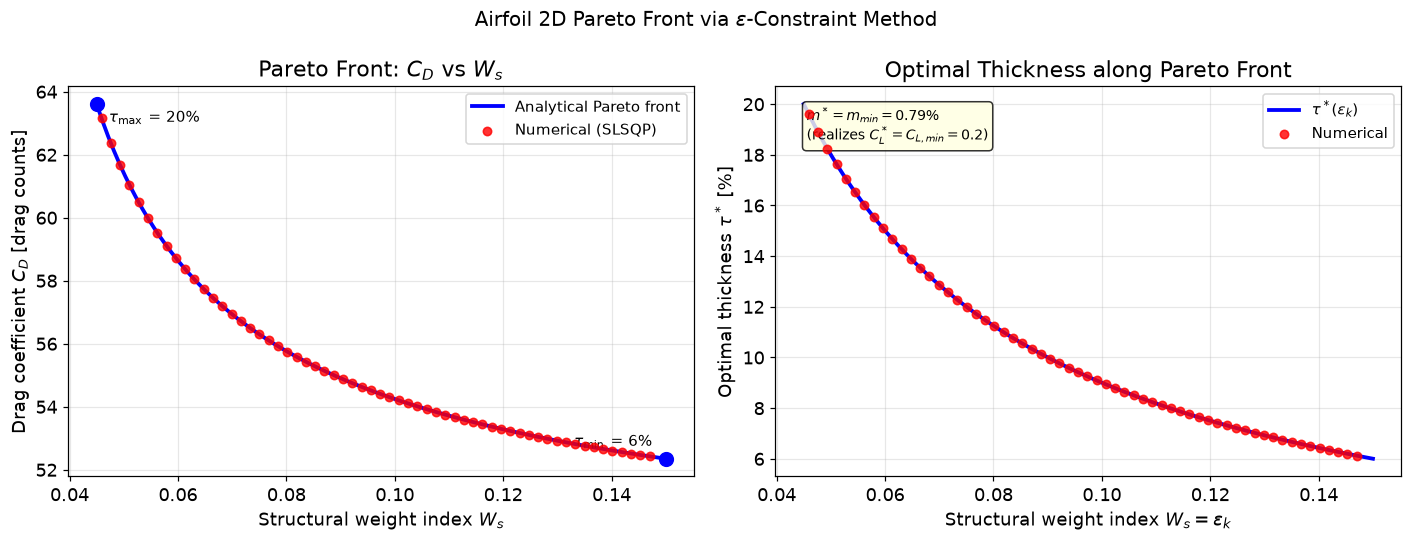

In [38]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: Pareto front in objective space
ax = axes[0]
ax.plot(Ws_pareto, CD_pareto * 1e4, 'b-', lw=2.5, label='Analytical Pareto front')
ax.scatter(Ws_num, CD_num * 1e4, color='red', s=30, zorder=5,
           label='Numerical (SLSQP)', alpha=0.8)
# Mark the two endpoints
ax.scatter([Ws_pareto[0], Ws_pareto[-1]],
           [CD_pareto[0]*1e4, CD_pareto[-1]*1e4],
           color='blue', s=80, zorder=6)
ax.annotate(f'$\\tau_{{\\max}}$ = {tau_max*100:.0f}%',
            (Ws_pareto[0], CD_pareto[0]*1e4), textcoords='offset points',
            xytext=(8, -12), fontsize=10)
ax.annotate(f'$\\tau_{{\\min}}$ = {tau_min*100:.0f}%',
            (Ws_pareto[-1], CD_pareto[-1]*1e4), textcoords='offset points',
            xytext=(-60, 8), fontsize=10)
ax.set_xlabel('Structural weight index $W_s$')
ax.set_ylabel('Drag coefficient $C_D$ [drag counts]')
ax.set_title('Pareto Front: $C_D$ vs $W_s$')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

# Right: optimal design variables along Pareto front
ax = axes[1]
ax.plot(Ws_pareto, tau_pareto * 100, 'b-', lw=2.5, label='$\\tau^*(\\varepsilon_k)$')
ax.scatter(Ws_num, tau_num * 100, color='red', s=30, zorder=5, alpha=0.8, label='Numerical')
ax.set_xlabel('Structural weight index $W_s = \\varepsilon_k$')
ax.set_ylabel('Optimal thickness $\\tau^*$ [%]')
ax.set_title('Optimal Thickness along Pareto Front')
# Add a note about the camber design variable and its computed CL
ax.text(0.05, 0.95, f'$m^* = m_{{min}} = {m_min*100:.2f}\\%$\n(realizes $C_L^*=C_{{L,min}}={CL_min}$)',
        transform=ax.transAxes, fontsize=9,
        verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

plt.suptitle('Airfoil 2D Pareto Front via $\\varepsilon$-Constraint Method', fontsize=13)
plt.tight_layout()
plt.show()

---
## 6. Parametric Study: Effect of Aspect Ratio $AR$

The Pareto front is a function of the parameters $\mathbf{p} = [AR, e, c_f, \ldots]$.
We vary the **aspect ratio** $AR$ and observe how the Pareto front shifts. Along the Pareto
front $C_L^* = C_{L,\min}$ always (Section 4), so this sensitivity study is expressed directly
in the physical lift coefficient — it does not depend on how $C_L$ is realized in shape space.

> Higher $AR$ → lower induced drag → lower $C_D$ for same $\tau$ → Pareto front moves down
> (less drag for a given structural weight).


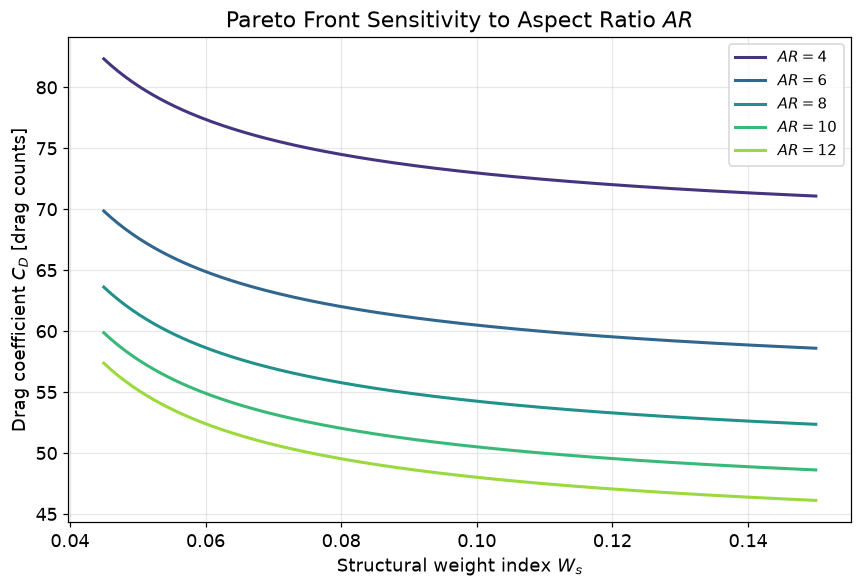

In [39]:
AR_values  = [4, 6, 8, 10, 12]
colors     = plt.cm.viridis(np.linspace(0.15, 0.85, len(AR_values)))

fig, ax = plt.subplots(figsize=(8, 5.5))

for AR_k, color in zip(AR_values, colors):
    def CD_total_k(tau, CL, AR_=AR_k):
        return CD_profile(tau) + CL**2 / (np.pi * AR_ * e)

    CD_k = CD_total_k(tau_pareto, CL_min)
    ax.plot(Ws_pareto, CD_k * 1e4, color=color, lw=2,
            label=f'$AR = {AR_k}$')

ax.set_xlabel('Structural weight index $W_s$')
ax.set_ylabel('Drag coefficient $C_D$ [drag counts]')
ax.set_title('Pareto Front Sensitivity to Aspect Ratio $AR$')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

# Annotate direction of improvement
ax.annotate('Increasing $AR$\n(less induced drag)',
            xy=(0.09, 190), xytext=(0.105, 220),
            arrowprops=dict(arrowstyle='->', color='gray'),
            fontsize=10, color='gray')

plt.tight_layout()
plt.show()

---
## 7. Putting It Together: Design Space with Pareto Front

The Pareto-optimal solutions lie on the line $C_L = C_{L,\min}$ in objective space (induced drag
minimized), realized by the constant camber $m = m_{\min}$, with $\tau$ sweeping from
$\tau_{\min}$ to $\tau_{\max}$. Because $C_L(m)$ is monotone, the design space can equivalently
be drawn with $C_L$ (computed) as the vertical axis — the Pareto path is a straight horizontal
line either way.


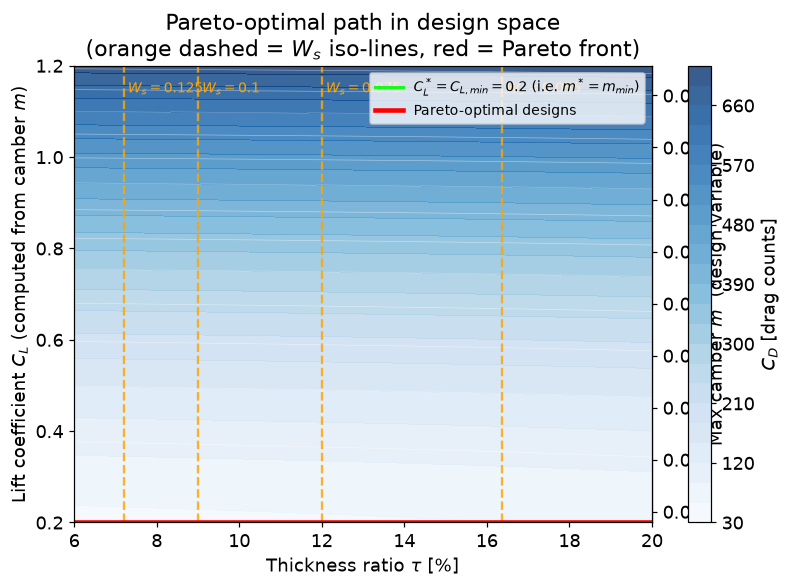

In [40]:
fig, ax = plt.subplots(figsize=(7.5, 5.5))

# CD contours in design space (tau, CL) -- CL is the computed quantity from Section 2
cs = ax.contourf(tau_vals * 100, CL_vals, CD_grid * 1e4, levels=25, cmap='Blues', alpha=0.8)
cbar = plt.colorbar(cs, ax=ax, label='$C_D$ [drag counts]')
ax.contour(tau_vals * 100, CL_vals, CD_grid * 1e4, levels=15,
           colors='white', linewidths=0.4, alpha=0.5)

# Ws iso-contours (vertical lines in tau-CL space)
Ws_levels = [0.055, 0.075, 0.10, 0.125]
for ws_val in Ws_levels:
    tau_line = k_s / ws_val
    if tau_min <= tau_line <= tau_max:
        ax.axvline(tau_line * 100, color='orange', ls='--', lw=1.5, alpha=0.85)
        ax.text(tau_line * 100 + 0.1, CL_max * 0.97,
                f'$W_s={ws_val}$', color='orange', fontsize=9, va='top')

# Pareto-optimal path in design space
ax.axhline(CL_min, color='lime', ls='-', lw=2, alpha=0.9, label=f'$C_L^*=C_{{L,min}}={CL_min}$ (i.e. $m^*=m_{{min}}$)')
ax.plot(tau_pareto * 100, CL_pareto, 'r-', lw=3, label='Pareto-optimal designs')

ax.set_xlabel('Thickness ratio $\\tau$ [%]')
ax.set_ylabel('Lift coefficient $C_L$ (computed from camber $m$)')
secax = ax.secondary_yaxis('right', functions=(m_of_CL, CL_of_m))
secax.set_ylabel('Max camber $m$  (design variable)')
ax.set_title('Pareto-optimal path in design space\n'
             '(orange dashed = $W_s$ iso-lines, red = Pareto front)')
ax.legend(fontsize=9, loc='upper right')
ax.grid(False)
plt.tight_layout()
plt.show()

---
## Summary

| Quantity | Expression | Key observation |
|---|---|---|
| $C_L(m)$ | $2\pi(\alpha_{\text{ref}} - \alpha_{L0}(m,p))$ | **computed**, monotone increasing in $m$ (thin-airfoil theory) |
| $C_{D,p}(\tau)$ | $c_f(1+2\tau+60\tau^4)$ | increases monotonically with $\tau$ |
| $C_{D,i}(m)$ | $C_L(m)^2/(\pi AR e)$ | increases monotonically with $m$ |
| $W_s(\tau)$ | $k_s/\tau$ | decreases monotonically with $\tau$ |
| Optimal $m^*$ | $m_{\min}$ | lower bound always active (realizes $C_L^*=C_{L,\min}$) |
| Optimal $\tau^*(\varepsilon_k)$ | $k_s/\varepsilon_k$ | structural bound always active |

**Key takeaways:**
- The **NACA four-digit parameters** $(\tau, m)$ — thickness and maximum camber — are the true
  independent design variables; the camber position $p$ and operating angle of attack
  $\alpha_{\text{ref}}$ are held fixed as model parameters.
- $C_L$ is **never chosen directly**. It is computed from the shape via thin-airfoil theory,
  $C_L(m) = 2\pi(\alpha_{\text{ref}} - \alpha_{L0}(m,p))$, from Section 1 sanity check through
  the final Pareto-front plot — exactly like $C_D$ and $W_s$ are computed quantities.
- $C_D$ and $W_s$ are **competing** in $\tau$: the Pareto front is traced by sweeping $\varepsilon_k$.
- $m^* = m_{\min}$ for all Pareto-optimal solutions — i.e. $C_L^* = C_{L,\min}$ — the camber
  sub-problem is unconstrained and has a corner optimum; extra camber (and hence extra lift)
  beyond the mission's minimum requirement is never worth its induced-drag penalty.
- The $\varepsilon$-constraint structural bound is **always active**: every single-objective
  solution ($\min C_D$ for a fixed $\varepsilon_k$) corresponds to exactly one Pareto point.
- Increasing the aspect ratio $AR$ shifts the entire Pareto front downward — the
  tradeoff curve is a **function of the parameters** $\mathbf{p}$.
